# Lecture 08, Notebook 09: 56-Agent OLG Benchmark — DEQN (Exogenous Sampling)

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §5.6 (the 56-agent Azinovic–Gaegauf–Scheidegger 2022 benchmark; two assets, borrowing/collateral constraints, persistent shocks); §5.3–§5.4 (DEQN mapping, product-form KKT)  
**Notebook role:** core  
**Author:** Simon Scheidegger

---

This notebook solves the 56-period overlapping-generations benchmark of Azinovic, Gaegauf and Scheidegger (2022): risky illiquid capital, a risk-free one-period bond, cohort-specific borrowing and collateral constraints, lifecycle labor income, and aggregate TFP / depreciation shocks. The equilibrium conditions are the cohort-stacked capital and bond Euler equations, product-form KKT complementarity residuals for the borrowing and collateral inequalities ($\lambda_b^h\,k'^h$ and $\mu^h\,q^h$, both squared in the loss), and an explicit bond-market clearing residual.

The notebook mirrors the structure of the IRBC and analytic-OLG notebooks: parameters, augmented state, neural-network policy transform, residual / loss construction, training-data generation, mini-batch training, out-of-sample residual tables, policy-stability checks, and lifecycle plots.

In this notebook the training cloud is **drawn exogenously** from broad feasible boxes — useful for stress-testing the residual code without the additional feedback created by simulation. The complementary persistent-simulation companion (`lecture_08_10_OLG_Benchmark_DEQN_persistent.ipynb`) is the primary classroom variant and trains on the model's own ergodic set. Both expose a `RUN_MODE = "smoke" / "teaching" / "production"` switch (mirrored by the in-notebook `MODE` variable).

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

In [1]:
SAMPLING_MODE = "exogenous"

# ============================================================
# Imports, random seeds, and main switches
# ============================================================
import math
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.size"] = 12

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Training-budget switch
# ------------------------------------------------------------
# smoke      : quick code check
# teaching   : useful classroom run
# production : paper-like scale; intended for GPU/HPC runs
MODE = RUN_MODE                # mirrors the run-mode switch in the second cell

if MODE == "smoke":
    NUM_SEGMENTS = 25
    N_TRAJECTORIES = 8
    SIMULATION_LENGTH = 16
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 5
    EVAL_TRACKS = 8
    EVAL_BURN_IN = 8
    EVAL_LENGTH = 16
    HIDDEN_UNITS = 128
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=3e-4, batch_size=128),
    ]
elif MODE == "teaching":
    NUM_SEGMENTS = 301
    N_TRAJECTORIES = 16
    SIMULATION_LENGTH = 64
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 10
    EVAL_TRACKS = 32
    EVAL_BURN_IN = 64
    EVAL_LENGTH = 128
    HIDDEN_UNITS = 128
    TRAINING_SCHEDULE = [
        dict(until=NUM_SEGMENTS, learning_rate=2e-4, batch_size=512),
    ]
elif MODE == "production":
    # The paper uses two hidden layers with 1000 ReLU units, 10,000 states per
    # episode, and a long two-stage learning-rate schedule.  This preset keeps
    # the same scale; it is not meant for a laptop smoke run.
    NUM_SEGMENTS = 200_000
    N_TRAJECTORIES = 1_000
    SIMULATION_LENGTH = 10
    PASSES_PER_SEGMENT = 1
    MONITOR_EVERY = 1_000
    EVAL_TRACKS = 64
    EVAL_BURN_IN = 512
    EVAL_LENGTH = 256
    HIDDEN_UNITS = 1_000
    TRAINING_SCHEDULE = [
        dict(until=60_000, learning_rate=1e-5, batch_size=64),
        dict(until=200_000, learning_rate=1e-6, batch_size=1_000),
    ]
else:
    raise ValueError(f"Unknown MODE: {MODE}")

STATES_PER_SEGMENT = N_TRAJECTORIES * SIMULATION_LENGTH
SHUFFLE_STATES_WITHIN_SEGMENT = True
OPTIMIZER_NAME = "Adam"
CLIP_NORM = 10.0

# Loss weights.  The Euler residuals are relative consumption wedges; the other
# components are scaled in the residual function below.
EULER_WEIGHT = 1.0
KKT_WEIGHT = 1.0
MARKET_WEIGHT = 1.0
PENALTY_WEIGHT = 10.0

# Monitoring on a fixed holdout cloud, as in the IRBC notebook.  The network has
# no calendar-time input, so same-state repeatability is exact; the useful check
# is whether the learned function is still moving across SGD updates.
TIME_INVARIANCE_ANCHOR_STATES = 256 if MODE == "smoke" else 2048
TIME_INVARIANCE_TOL_RMS = 1.0e-3
TIME_INVARIANCE_TOL_MAX = 1.0e-2

print(f"TensorFlow version: {tf.__version__}")
print(f"SAMPLING_MODE = {SAMPLING_MODE}")
print(f"MODE = {MODE}")
print(f"states per segment = {STATES_PER_SEGMENT}")
print(f"hidden units = {HIDDEN_UNITS}")


2026-05-05 22:42:23.916209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 22:42:23.916969: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 22:42:23.921254: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 22:42:23.931812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778013743.949887   24615 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778013743.95

TensorFlow version: 2.19.0
SAMPLING_MODE = exogenous
MODE = smoke
states per segment = 128
hidden units = 128


## 1. Economic parameters

---

The Azinovic–Gaegauf–Scheidegger (2022) benchmark calibration: $A = 56$ overlapping agents (ages 25–80), Cobb–Douglas production, lifecycle labor profile, cohort-specific borrowing and collateral constraints, convex capital adjustment costs, and four i.i.d. aggregate-shock states combining TFP $\eta$ and depreciation $\delta$. The full constants are listed in the configuration block of the next code cell.


=== Benchmark OLG parameters ===
N_AGES = 56, raw state dim = 113, feature dim = 240
policy dim = 221
BETA = 0.95, GAMMA = 2.0, ALPHA = 0.3, ZETA = 0.5, KAPPA = 1.1236
Transition matrix PI:
[[0.87965995 0.09234    0.02534    0.00266   ]
 [0.09234    0.87965995 0.00266    0.02534   ]
 [0.2715     0.0285     0.6335     0.0665    ]
 [0.0285     0.2715     0.0665     0.6335    ]]
Labor: total=57.777, min=0.600, max=1.362


E0000 00:00:1778013748.894115   24615 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778013748.895968   24615 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


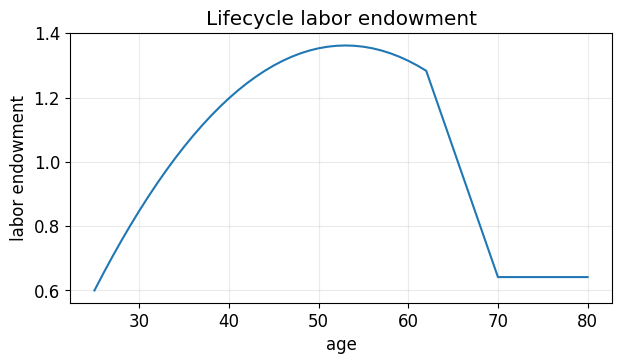

In [2]:
# ============================================================
# Benchmark OLG parameters
# ============================================================
N_AGES = 56
NUM_SHOCKS = 4
AGES = np.arange(25, 25 + N_AGES)

# Preferences and technology
BETA = 0.95
GAMMA = 2.0
ALPHA = 0.30
ZETA = 0.50
BORROWING_LIMIT_A = 0.0

# Aggregate shocks: order is
#   0 = low TFP, normal depreciation
#   1 = high TFP, normal depreciation
#   2 = low TFP, disaster depreciation
#   3 = high TFP, disaster depreciation
TFP = np.array([0.978, 1.022, 0.978, 1.022], dtype=np.float32)
DEPR = np.array([0.080, 0.080, 0.110, 0.110], dtype=np.float32)
KAPPA = 1.0 / (1.0 - float(np.max(DEPR)))

# Independent Markov chains for TFP and depreciation.
PI_DEPR = np.array([[0.972, 0.028],
                    [0.300, 0.700]], dtype=np.float32)
PI_TFP = np.array([[0.905, 0.095],
                   [0.095, 0.905]], dtype=np.float32)
PI = np.kron(PI_DEPR, PI_TFP).astype(np.float32)
PI_CUM = np.cumsum(PI, axis=1)

# Lifecycle labor endowment.  This is the smooth hump-shaped profile used in
# the notebook supplied with the course materials and is consistent with the
# benchmark description in the paper.
LABOR = np.zeros(N_AGES, dtype=np.float32)
A_IS = int(2.0 * N_AGES / 3.0)
A_DECR = int(5.0 * N_AGES / 6.0)
temp_l = 0.6 + (0.6 * 1.27 / (N_AGES / 2.0) ** 2) * ((N_AGES / 2.0) ** 2 - (A_IS - (N_AGES / 2.0)) ** 2)
for a in range(N_AGES):
    if a < A_IS:
        LABOR[a] = 0.6 + (0.6 * 1.27 / (N_AGES / 2.0) ** 2) * ((N_AGES / 2.0) ** 2 - (a - (N_AGES / 2.0)) ** 2)
    elif a < A_DECR:
        LABOR[a] = temp_l - 0.5 * temp_l * (a - A_IS) / (A_DECR - 1 - A_IS)
    else:
        LABOR[a] = 0.5 * temp_l
L_TOTAL = float(np.sum(LABOR))

# Tensor constants
TFP_TF = tf.constant(TFP.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
DEPR_TF = tf.constant(DEPR.reshape(NUM_SHOCKS, 1), dtype=tf.float32)
PI_TF = tf.constant(PI, dtype=tf.float32)
LABOR_TF = tf.constant(LABOR.reshape(1, N_AGES), dtype=tf.float32)
L_TOTAL_TF = tf.constant(L_TOTAL, dtype=tf.float32)

RAW_STATE_DIM = 1 + 2 * N_AGES       # [z, k_1,...,k_N, b_1,...,b_N]
FEATURE_DIM = 1 + NUM_SHOCKS + 2 + 5 + 4 * N_AGES + NUM_SHOCKS
N_CHOICES = N_AGES - 1
POLICY_DIM = 4 * N_CHOICES + 1       # [a, lambda, d-raw, mu, p]

print("=== Benchmark OLG parameters ===")
print(f"N_AGES = {N_AGES}, raw state dim = {RAW_STATE_DIM}, feature dim = {FEATURE_DIM}")
print(f"policy dim = {POLICY_DIM}")
print(f"BETA = {BETA}, GAMMA = {GAMMA}, ALPHA = {ALPHA}, ZETA = {ZETA}, KAPPA = {KAPPA:.4f}")
print("Transition matrix PI:")
print(PI)
print(f"Labor: total={L_TOTAL:.3f}, min={LABOR.min():.3f}, max={LABOR.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(AGES, LABOR)
ax.set_title("Lifecycle labor endowment")
ax.set_xlabel("age")
ax.set_ylabel("labor endowment")
ax.grid(alpha=0.25)
plt.show()


## 2. State representation and augmented network inputs

---

The minimal state stacks the cohort capital and bond holdings with the aggregate shock; the network input augments this with pre-computed aggregates, prices, and the shock-transition row,

$$
  \mathbf{s}_t = \bigl(\mathbf{k}_t, \mathbf{b}_t, K_t, B_t, r_t, w_t, q_t, \eta_t, \delta_t, \boldsymbol{\pi}(z_t)\bigr) \in \mathbb{R}^{236},
$$

where $\mathbf{k}_t, \mathbf{b}_t \in \mathbb{R}^A$ are cohort capital and bond positions, $K_t, B_t$ are their aggregates, $(r_t, w_t, q_t)$ are the equilibrium prices (including the bond price $q_t$), and $\boldsymbol{\pi}(z_t)$ is the shock transition row. The minimal state has dimension 113; the augmentation to 236 is feature engineering only.


In [3]:
# ============================================================
# State representation, firm prices, and network features
# ============================================================
EPS = 1.0e-8
CONSUMPTION_FLOOR = 1.0e-6

# Feature scales.  These are numerical normalizations, not equilibrium targets.
ASSET_SCALE = 1.0
AGG_K_SCALE = max(1.0, 0.5 * N_AGES)
AGG_L_SCALE = max(1.0, L_TOTAL)
PRICE_SCALE = 1.0
OUTPUT_SCALE = max(1.0, L_TOTAL)

# Broad feasible boxes for training states and initial simulation heads.  They
# are deliberately rectangular/random and do not encode a steady-state or
# lifecycle profile.
EXOGENOUS_K_LOW = 0.02
EXOGENOUS_K_HIGH = 1.25
EXOGENOUS_BOND_POS_MAX = 0.75
EXOGENOUS_BOND_NEG_FRACTION = 0.90

INITIAL_K_LOW = 0.02
INITIAL_K_HIGH = 1.25
INITIAL_BOND_POS_MAX = 0.75
INITIAL_BOND_NEG_FRACTION = 0.90

EMERGENCY_REPAIR_BAD_STATES = True
SIM_REPAIR_AGG_K_MIN = 1.0e-4
SIM_REPAIR_AGG_K_MAX = 10.0 * N_AGES
SIM_REPAIR_ABS_B_MAX = 25.0


def unpack_state(states):
    """Return integer shock indices, capital holdings, and bond holdings."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z = tf.cast(tf.round(states[:, 0]), tf.int32)
    k = states[:, 1:1 + N_AGES]
    b = states[:, 1 + N_AGES:1 + 2 * N_AGES]
    return z, k, b


def assemble_states_tf(z, k, b):
    """Assemble a TensorFlow raw state array."""
    z = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    return tf.concat([z, tf.cast(k, tf.float32), tf.cast(b, tf.float32)], axis=1)


def assemble_states_np(z, k, b):
    """Assemble a NumPy raw state array."""
    return np.concatenate([
        np.asarray(z, dtype=np.float32).reshape(-1, 1),
        np.asarray(k, dtype=np.float32),
        np.asarray(b, dtype=np.float32),
    ], axis=1).astype(np.float32)


def firm_prices_from_components(K, eta, depr):
    """Return r, w, and aggregate output for the OLG production function."""
    K_safe = tf.maximum(tf.cast(K, tf.float32), EPS)
    L = tf.ones_like(K_safe) * L_TOTAL_TF
    eta = tf.cast(eta, tf.float32)
    depr = tf.cast(depr, tf.float32)
    r = ALPHA * eta * tf.pow(K_safe, ALPHA - 1.0) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr)
    w = (1.0 - ALPHA) * eta * tf.pow(K_safe, ALPHA) * tf.pow(L, -ALPHA)
    Y = eta * tf.pow(K_safe, ALPHA) * tf.pow(L, 1.0 - ALPHA) + (1.0 - depr) * K_safe
    return r, w, Y


def state_prices(states):
    """Prices and aggregates implied by the raw state."""
    z, k, _ = unpack_state(states)
    eta = tf.gather(TFP_TF, z)
    depr = tf.gather(DEPR_TF, z)
    K = tf.reduce_sum(k, axis=1, keepdims=True)
    r, w, Y = firm_prices_from_components(K, eta, depr)
    return K, r, w, Y, eta, depr


def current_cash_before_choices(states):
    """Cash-on-hand before current choices: r k + b + w l."""
    _, k, b = unpack_state(states)
    K, r, w, Y, eta, depr = state_prices(states)
    labor_income = w * LABOR_TF
    financial_income = r * k + b
    cash = financial_income + labor_income
    return cash, labor_income, financial_income, K, r, w, Y, eta, depr


def network_features(states):
    """Build the 236-dimensional augmented input used by the neural net.

    The raw state remains [z, k, b].  The augmentation supplies the same type of
    redundant economic information used in the paper and in the IRBC notebook:
    shock indicators, transition probabilities, prices, capital, financial
    income, labor income, and total cash-on-hand.
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    z, k, _ = unpack_state(states)
    cash, labor_income, financial_income, K, r, w, Y, eta, depr = current_cash_before_choices(states)
    z_float = tf.cast(tf.reshape(z, [-1, 1]), tf.float32)
    one_hot_z = tf.one_hot(z, NUM_SHOCKS, dtype=tf.float32)
    transition_row = tf.gather(PI_TF, z)
    features = tf.concat([
        z_float / max(1.0, NUM_SHOCKS - 1.0),
        one_hot_z,
        eta,
        depr,
        K / AGG_K_SCALE,
        tf.ones_like(K) * (L_TOTAL / AGG_L_SCALE),
        r / PRICE_SCALE,
        w / PRICE_SCALE,
        Y / OUTPUT_SCALE,
        k / ASSET_SCALE,
        financial_income / ASSET_SCALE,
        labor_income / ASSET_SCALE,
        cash / ASSET_SCALE,
        transition_row,
    ], axis=1)
    return features


# Quick dimension check on random raw states.
_X_dim_check = np.zeros((3, RAW_STATE_DIM), dtype=np.float32)
_X_dim_check[:, 0] = np.arange(3) % NUM_SHOCKS
_X_dim_check[:, 1:1 + N_AGES] = 0.1
_X_dim_check[:, 1] = 0.0
_X_dim_check[:, 1 + N_AGES] = 0.0
assert int(network_features(_X_dim_check).shape[1]) == FEATURE_DIM
print(f"network feature dimension check passed: {FEATURE_DIM}")


network feature dimension check passed: 240


## 3. Neural network and policy transformation

---

The policy network outputs four blocks of cohort-specific quantities plus the bond price:

$$
  \mathcal{N}_\theta(\mathbf{s}_t) \;\longrightarrow\; \bigl(\hat{k}_{t+1}^h,\, \hat{\lambda}_b^{h},\, \hat{q}^h,\, \hat{\mu}^h\bigr)_{h=1}^{A-1} \;\cup\; \{\hat{q}_t\},
$$

for a total of $4(A-1) + 1 = 221$ outputs. Softplus heads enforce $\hat{k}_{t+1}^h, \hat{\lambda}_b^h, \hat{\mu}^h \ge 0$ by construction (the bond holding is recovered as $\hat{b}_{t+1}^h = (\hat{q}^h - \hat{k}_{t+1}^h)/\kappa$). The borrowing and collateral inequalities are then enforced softly via squared product-form KKT residuals ($\lambda_b^h\,k'^h$ and $\mu^h\,q^h$), defined in §4.


In [4]:
# ============================================================
# Neural network and economically admissible policy transform
# ============================================================
# The last layer is initialized at zero.  With the transformations below, zero
# raw outputs imply a dispersed, feasible, low-leverage rule: positive capital
# saving, zero bond position, p approx beta, and small multipliers.  This is a
# numerical initialization only; training states are not initialized at a steady
# state and no target policy is supplied.
CAPITAL_LOG_SCALE = 1.50
BOND_LOG_SCALE = 2.50
PRICE_LOG_SCALE = 0.50
MULTIPLIER_SCALE = 0.10
MULTIPLIER_BIAS = -4.0
MIN_CAPITAL_CHOICE = 1.0e-5
CAPITAL_BASE_MIN = 0.02
CAPITAL_BASE_MAX = 0.75


def build_network():
    return keras.Sequential([
        keras.layers.Input(shape=(FEATURE_DIM,)),
        keras.layers.Dense(HIDDEN_UNITS, activation="relu"),
        keras.layers.Dense(HIDDEN_UNITS, activation="relu"),
        keras.layers.Dense(
            POLICY_DIM,
            activation=None,
            kernel_initializer="zeros",
            bias_initializer="zeros",
        ),
    ], name="OLG_DEQN_benchmark")


def split_raw_output(raw):
    raw_a = raw[:, 0:N_CHOICES]
    raw_lambda = raw[:, N_CHOICES:2 * N_CHOICES]
    raw_d = raw[:, 2 * N_CHOICES:3 * N_CHOICES]
    raw_mu = raw[:, 3 * N_CHOICES:4 * N_CHOICES]
    raw_p = raw[:, 4 * N_CHOICES:4 * N_CHOICES + 1]
    return raw_a, raw_lambda, raw_d, raw_mu, raw_p


def policy(states, model):
    """Map raw states to admissible policies.

    Returns
    -------
    a      : capital investment for ages 1,...,N-1
    lam    : KKT multipliers for the capital borrowing constraint
    d      : one-period bond purchases for ages 1,...,N-1
    mu     : KKT multipliers for the collateral constraint
    p      : bond price
    coll   : collateral slack a + kappa d, nonnegative by construction
    """
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    raw = model(network_features(states))
    raw_a, raw_lambda, raw_d, raw_mu, raw_p = split_raw_output(raw)

    cash, _, _, _, _, _, _, _, _ = current_cash_before_choices(states)
    cash_choice = cash[:, :N_CHOICES]

    # State-dependent positive baseline: a simple feasible numerical scale, not
    # an equilibrium target.  The network learns multiplicative deviations.
    a_base = 0.20 * tf.maximum(cash_choice, 0.0) + CAPITAL_BASE_MIN
    a_base = tf.clip_by_value(a_base, CAPITAL_BASE_MIN, CAPITAL_BASE_MAX)
    a = tf.maximum(a_base * tf.exp(CAPITAL_LOG_SCALE * tf.tanh(raw_a)), MIN_CAPITAL_CHOICE)

    # Collateral constraint d >= -a/kappa.  Zero raw_d gives d = 0.
    d_positive_component = tf.maximum(a / KAPPA, EPS) * tf.exp(BOND_LOG_SCALE * tf.tanh(raw_d))
    d = -a / KAPPA + d_positive_component
    coll = a + KAPPA * d

    lam = MULTIPLIER_SCALE * tf.nn.softplus(raw_lambda + MULTIPLIER_BIAS)
    mu = MULTIPLIER_SCALE * tf.nn.softplus(raw_mu + MULTIPLIER_BIAS)
    p = BETA * tf.exp(PRICE_LOG_SCALE * tf.tanh(raw_p))
    return a, lam, d, mu, p, coll


def policy_fingerprint(states, model):
    """Dimensionless policy vector for policy-drift diagnostics."""
    a, lam, d, mu, p, _ = policy(states, model)
    return tf.concat([
        tf.math.log1p(a),
        d / (1.0 + tf.abs(d)),
        tf.math.log(tf.maximum(lam, EPS)),
        tf.math.log(tf.maximum(mu, EPS)),
        tf.math.log(tf.maximum(p, EPS) / BETA),
    ], axis=1)


def relative_policy_drift(previous, current):
    previous = np.asarray(previous, dtype=np.float64)
    current = np.asarray(current, dtype=np.float64)
    diff = current - previous
    scale = 1.0 + np.sqrt(np.mean(previous ** 2))
    return float(np.sqrt(np.mean(diff ** 2)) / scale), float(np.max(np.abs(diff)) / scale)


model_check = build_network()
a0, lam0, d0, mu0, p0, coll0 = policy(_X_dim_check, model_check)
print("Initial-policy smoke check")
print(f"  mean a      = {float(tf.reduce_mean(a0)):.4f}")
print(f"  mean d      = {float(tf.reduce_mean(d0)):.4e}")
print(f"  mean p      = {float(tf.reduce_mean(p0)):.4f}")
print(f"  min coll    = {float(tf.reduce_min(coll0)):.4e}")


Initial-policy smoke check
  mean a      = 0.1395
  mean d      = 0.0000e+00
  mean p      = 0.9500
  min coll    = 6.0570e-02


## 4. Residuals and loss

---

For each cohort $h = 1, \ldots, A-1$ there is a capital Euler, a bond Euler, and two complementarity residuals. The capital Euler in relative form is

$$
  \mathrm{EulerErr}_h^{(k)}(\mathbf{s}_t) \;=\;
  \frac{\beta\, \mathbb{E}_t\!\left[\, u'(c_{t+1}^{h+1})\, \bigl(R_{t+1} + 1 - \delta_{t+1}\bigr)\,\right]}
       {u'(c_t^h)\,\bigl(1 + \zeta(k_{t+1}^h - r\,k_t^h)\bigr)} \;-\; 1,
$$

with the analogous residual for the bond. Borrowing- and collateral-constraint complementarity is enforced softly by adding *squared product residuals* to the loss:

$$
  \mathrm{KKT}_{\mathrm{borrow}}^h \;=\; \lambda_b^h \cdot k'^h, \qquad
  \mathrm{KKT}_{\mathrm{coll}}^h \;=\; \mu^h \cdot q^h.
$$

Both vanish exactly at any KKT point and have a differentiable squared form. (The Fischer–Burmeister alternative $\Phi(a,b) = a + b - \sqrt{a^2 + b^2}$ is used in the IRBC notebook of Chapter 3, where the irreversibility constraint binds more often.) Bond-market clearing is enforced as a residual rather than by construction:

$$
  \mathrm{BondClear}(\mathbf{s}_t) \;=\;
  \sum_{h=1}^{A-1} b_{t+1}^h \;=\; 0.
$$

The total loss is the mean-squared sum of all $4(A-1) + 1 = 221$ residuals; the `KKT_WEIGHT` and `MARKET_WEIGHT` constants in the configuration cell put the complementarity and market-clearing residuals on the same scale as the Euler errors.


In [5]:
# ============================================================
# Residuals and loss
# ============================================================

def marginal_utility(c):
    return tf.pow(tf.maximum(c, CONSUMPTION_FLOOR), -GAMMA)


def inverse_marginal_utility(x):
    return tf.pow(tf.maximum(x, CONSUMPTION_FLOOR), -1.0 / GAMMA)


def consumption_and_adjustment(states, a, d, p):
    """Budget constraint for all ages, including a_N=d_N=0."""
    _, k, b = unpack_state(states)
    cash, labor_income, financial_income, K, r, w, Y, eta, depr = current_cash_before_choices(states)
    a_all = tf.concat([a, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    d_all = tf.concat([d, tf.zeros([tf.shape(states)[0], 1], dtype=tf.float32)], axis=1)
    adjustment = a_all - r * k
    adjustment_cost = 0.5 * ZETA * tf.square(adjustment)
    c_raw = cash - a_all - p * d_all - adjustment_cost
    return c_raw, adjustment, K, r, w, Y


@tf.function
def compute_residuals(states, model):
    """Return the DEQN loss and residual components on a state batch."""
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    m = tf.shape(states)[0]
    z, _, _ = unpack_state(states)
    probs_next = tf.gather(PI_TF, z)

    a, lam, d, mu, p, coll = policy(states, model)
    c_raw, adjustment, K, r, w, Y = consumption_and_adjustment(states, a, d, p)
    c = tf.maximum(c_raw, CONSUMPTION_FLOOR)

    k_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), a], axis=1)
    b_next = tf.concat([tf.zeros([m, 1], dtype=tf.float32), d], axis=1)

    expected_capital = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    expected_bond = tf.zeros([m, N_CHOICES], dtype=tf.float32)
    future_c_raw = []
    future_adj_factors = []

    for shock in range(NUM_SHOCKS):
        z_next = tf.ones([m], dtype=tf.float32) * float(shock)
        x_next = assemble_states_tf(z_next, k_next, b_next)
        a_next, _, d_next, _, p_next, _ = policy(x_next, model)
        c_next_raw, adjustment_next, _, r_next, _, _ = consumption_and_adjustment(x_next, a_next, d_next, p_next)
        c_next = tf.maximum(c_next_raw, CONSUMPTION_FLOOR)

        prob = probs_next[:, shock:shock + 1]
        future_marginal = marginal_utility(c_next[:, 1:N_AGES])
        adj_factor_next = 1.0 + ZETA * adjustment_next[:, 1:N_AGES]
        expected_capital += prob * r_next * adj_factor_next * future_marginal
        expected_bond += prob * future_marginal
        future_c_raw.append(c_next_raw)
        future_adj_factors.append(adj_factor_next)

    adj_factor_now = 1.0 + ZETA * adjustment[:, 0:N_CHOICES]
    adj_factor_now_safe = tf.maximum(adj_factor_now, CONSUMPTION_FLOOR)

    euler_cap_arg = (BETA * expected_capital + lam + mu) / adj_factor_now_safe
    euler_capital = inverse_marginal_utility(euler_cap_arg) / c[:, 0:N_CHOICES] - 1.0

    euler_bond_arg = (BETA * expected_bond + KAPPA * mu) / tf.maximum(p, CONSUMPTION_FLOOR)
    euler_bond = inverse_marginal_utility(euler_bond_arg) / c[:, 0:N_CHOICES] - 1.0

    kkt_capital = lam * a
    kkt_bond = mu * coll

    bond_market_raw = tf.reduce_sum(d, axis=1, keepdims=True)
    bond_market_scaled = bond_market_raw / (1.0 + tf.reduce_sum(tf.abs(d), axis=1, keepdims=True))
    bond_market_normalized = bond_market_raw / tf.maximum(Y, CONSUMPTION_FLOOR)

    all_c_raw = tf.concat([c_raw] + future_c_raw, axis=1)
    neg_c_penalty = tf.maximum(-all_c_raw, 0.0) / (1.0 + tf.abs(all_c_raw))

    all_adj_factors = tf.concat([adj_factor_now] + future_adj_factors, axis=1)
    bad_adj_penalty = tf.maximum(-all_adj_factors, 0.0) / (1.0 + tf.abs(all_adj_factors))

    loss = (
        EULER_WEIGHT * (tf.reduce_mean(tf.square(euler_capital)) + tf.reduce_mean(tf.square(euler_bond)))
        + KKT_WEIGHT * (tf.reduce_mean(tf.square(kkt_capital)) + tf.reduce_mean(tf.square(kkt_bond)))
        + MARKET_WEIGHT * tf.reduce_mean(tf.square(bond_market_scaled))
        + PENALTY_WEIGHT * (tf.reduce_mean(tf.square(neg_c_penalty)) + tf.reduce_mean(tf.square(bad_adj_penalty)))
    )

    components = {
        "euler_capital": euler_capital,
        "euler_bond": euler_bond,
        "kkt_capital": kkt_capital,
        "kkt_bond": kkt_bond,
        "bond_market_raw": bond_market_raw,
        "bond_market_scaled": bond_market_scaled,
        "bond_market_normalized": bond_market_normalized,
        "c_raw": c_raw,
        "c": c,
        "a": a,
        "d": d,
        "p": p,
        "lambda": lam,
        "mu": mu,
        "collateral_slack": coll,
        "K": K,
        "Y": Y,
        "negative_consumption_penalty": neg_c_penalty,
        "bad_adjustment_penalty": bad_adj_penalty,
    }
    return loss, components


_loss_check, _comp_check = compute_residuals(_X_dim_check, model_check)
print(f"initial residual finite: {np.isfinite(float(_loss_check.numpy()))}, loss = {float(_loss_check.numpy()):.3e}")


initial residual finite: True, loss = 8.379e-02


## Training-data construction

In this version, training states are drawn exogenously from broad feasible boxes. This is useful for checking the residual code without the additional feedback created by simulation. The state clouds are deliberately not centered on a deterministic steady state.


In [6]:
# ============================================================
# Training-data construction
# ============================================================

def _sample_feasible_box(n, k_low, k_high, bond_pos_max, bond_neg_fraction, local_rng):
    """Random feasible states from broad boxes; no lifecycle or steady-state prior."""
    z = local_rng.integers(0, NUM_SHOCKS, size=n).astype(np.float32)
    log_k = local_rng.uniform(np.log(k_low), np.log(k_high), size=(n, N_AGES)).astype(np.float32)
    k = np.exp(log_k).astype(np.float32)
    k[:, 0] = 0.0

    b_low = -bond_neg_fraction * k / KAPPA
    b_high = bond_pos_max * np.ones_like(k, dtype=np.float32)
    b = local_rng.uniform(b_low, b_high).astype(np.float32)
    b[:, 0] = 0.0
    return assemble_states_np(z, k, b)


def sample_exogenous_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 1000 + seed_offset)
    return _sample_feasible_box(
        n,
        EXOGENOUS_K_LOW,
        EXOGENOUS_K_HIGH,
        EXOGENOUS_BOND_POS_MAX,
        EXOGENOUS_BOND_NEG_FRACTION,
        local_rng,
    )


def sample_feasible_initial_states(n, seed_offset=0):
    local_rng = np.random.default_rng(SEED + 2000 + seed_offset)
    return _sample_feasible_box(
        n,
        INITIAL_K_LOW,
        INITIAL_K_HIGH,
        INITIAL_BOND_POS_MAX,
        INITIAL_BOND_NEG_FRACTION,
        local_rng,
    )


def draw_next_shocks(z_current):
    z_int = np.asarray(np.round(z_current), dtype=np.int64)
    u = rng.random(len(z_int))
    return np.sum(u[:, None] > PI_CUM[z_int], axis=1).astype(np.float32)


def one_step_transition(states_np, model, z_next_np):
    states_tf = tf.constant(states_np, dtype=tf.float32)
    a, _, d, _, _, _ = policy(states_tf, model)
    a_np = a.numpy().astype(np.float32)
    d_np = d.numpy().astype(np.float32)
    k_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), a_np], axis=1)
    b_next = np.concatenate([np.zeros((states_np.shape[0], 1), dtype=np.float32), d_np], axis=1)
    return assemble_states_np(z_next_np, k_next, b_next)


def bad_state_mask(states_np):
    states_np = np.asarray(states_np, dtype=np.float32)
    finite = np.all(np.isfinite(states_np), axis=1)
    z = states_np[:, 0]
    k = states_np[:, 1:1 + N_AGES]
    b = states_np[:, 1 + N_AGES:1 + 2 * N_AGES]
    K = np.sum(k, axis=1)
    collateral_ok = np.all(b >= -k / KAPPA - 1.0e-5, axis=1)
    mask_good = (
        finite
        & (z >= -0.5) & (z <= NUM_SHOCKS - 0.5)
        & np.all(k >= -1.0e-7, axis=1)
        & collateral_ok
        & (K >= SIM_REPAIR_AGG_K_MIN)
        & (K <= SIM_REPAIR_AGG_K_MAX)
        & np.all(np.abs(b) <= SIM_REPAIR_ABS_B_MAX, axis=1)
    )
    return ~mask_good


def simulate_path(X0, model, n_steps, seed_offset=0, return_time_major=False):
    """Simulate under the current learned policy.

    The initial states are supplied by sample_feasible_initial_states, not by a
    steady-state calculation.  Emergency repair only replaces numerically invalid
    states by fresh feasible-box draws.
    """
    X = np.asarray(X0, dtype=np.float32).copy()
    n_tracks = X.shape[0]
    path = np.empty((n_steps, n_tracks, RAW_STATE_DIM), dtype=np.float32)
    n_repaired = 0

    for t in range(n_steps):
        path[t] = X
        z_next = draw_next_shocks(X[:, 0])
        X_next = one_step_transition(X, model, z_next)
        if EMERGENCY_REPAIR_BAD_STATES:
            bad = bad_state_mask(X_next)
            if np.any(bad):
                n_bad = int(np.sum(bad))
                X_next[bad] = sample_feasible_initial_states(n_bad, seed_offset=seed_offset + 10_000 + t)
                n_repaired += n_bad
        X = X_next

    if return_time_major:
        return path, X, n_repaired
    return path.reshape(-1, RAW_STATE_DIM), X, n_repaired


def get_training_segment(X_start, model, segment_index):
    if SAMPLING_MODE == "exogenous":
        X = sample_exogenous_states(STATES_PER_SEGMENT, seed_offset=segment_index)
        return X, X_start, 0
    if SAMPLING_MODE == "simulation":
        return simulate_path(X_start, model, SIMULATION_LENGTH, seed_offset=segment_index)
    raise ValueError(f"Unknown SAMPLING_MODE: {SAMPLING_MODE}")


def sample_time_invariance_anchor_states(n):
    return sample_exogenous_states(n, seed_offset=999_001)


X_sampling_check = sample_exogenous_states(5)
print("sample state shape:", X_sampling_check.shape)
print("bad sampled states:", int(np.sum(bad_state_mask(X_sampling_check))))


sample state shape: (5, 113)
bad sampled states: 0


## 5. Mini-batches and training loop

---

A training segment may contain many states; the variables `BATCH_SIZE`, `PASSES_PER_SEGMENT`, and `OPTIMIZER_NAME` determine how the optimizer uses these states. The segment-continuation logic is intentionally explicit:

```python
X_segment, X_end = get_training_segment(X_start, model)
... optimizer updates on X_segment ...
X_start = X_end
```


In [7]:
# ============================================================
# Mini-batches, optimizer, and training loop
# ============================================================

def make_optimizer(learning_rate):
    if OPTIMIZER_NAME == "Adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "RMSprop":
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    if OPTIMIZER_NAME == "SGD":
        return keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0)
    raise ValueError(f"Unknown optimizer: {OPTIMIZER_NAME}")


def hyperparameters_for_segment(segment):
    for item in TRAINING_SCHEDULE:
        if segment < int(item["until"]):
            return float(item["learning_rate"]), int(item["batch_size"])
    item = TRAINING_SCHEDULE[-1]
    return float(item["learning_rate"]), int(item["batch_size"])


def set_optimizer_learning_rate(optimizer, learning_rate):
    try:
        optimizer.learning_rate.assign(learning_rate)
    except Exception:
        optimizer.learning_rate = learning_rate


def iterate_minibatches(X, batch_size):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    if SHUFFLE_STATES_WITHIN_SEGMENT:
        order = rng.permutation(n)
    else:
        order = np.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        if len(idx) > 0:
            yield tf.constant(X[idx], dtype=tf.float32)


@tf.function
def train_step(X_batch, model, optimizer):
    with tf.GradientTape() as tape:
        loss, _ = compute_residuals(X_batch, model)
    grads = tape.gradient(loss, model.trainable_variables)
    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    if CLIP_NORM is not None:
        grads, _ = tf.clip_by_global_norm(grads, CLIP_NORM)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_on_segment_states(X_segment, model, optimizer, batch_size):
    losses = []
    for _ in range(PASSES_PER_SEGMENT):
        for X_batch in iterate_minibatches(X_segment, batch_size):
            losses.append(float(train_step(X_batch, model, optimizer).numpy()))
    return float(np.mean(losses)), len(losses)


def summarize_monitor_components(components):
    return {
        "mean_abs_euler_capital": float(tf.reduce_mean(tf.abs(components["euler_capital"])).numpy()),
        "mean_abs_euler_bond": float(tf.reduce_mean(tf.abs(components["euler_bond"])).numpy()),
        "mean_abs_kkt_capital": float(tf.reduce_mean(tf.abs(components["kkt_capital"])).numpy()),
        "mean_abs_kkt_bond": float(tf.reduce_mean(tf.abs(components["kkt_bond"])).numpy()),
        "mean_abs_bond_market": float(tf.reduce_mean(tf.abs(components["bond_market_raw"])).numpy()),
        "share_negative_consumption": float(tf.reduce_mean(tf.cast(components["c_raw"] <= 0.0, tf.float32)).numpy()),
    }


model = build_network()
learning_rate_0, _batch_size_0 = hyperparameters_for_segment(0)
optimizer = make_optimizer(learning_rate_0)

X_start = sample_feasible_initial_states(N_TRAJECTORIES)
X_anchor = sample_time_invariance_anchor_states(TIME_INVARIANCE_ANCHOR_STATES)
anchor_fingerprint_previous = policy_fingerprint(tf.constant(X_anchor), model).numpy()

history = {
    "segment": [],
    "loss": [],
    "train_loss": [],
    "mean_abs_euler_capital": [],
    "mean_abs_euler_bond": [],
    "mean_abs_kkt_capital": [],
    "mean_abs_kkt_bond": [],
    "mean_abs_bond_market": [],
    "share_negative_consumption": [],
    "policy_drift_rms": [],
    "policy_drift_max": [],
    "K_min": [],
    "K_max": [],
    "repairs": [],
    "n_updates": [],
}

print("Starting training")
print(f"  segments: {NUM_SEGMENTS}")
print(f"  states per segment: {STATES_PER_SEGMENT}")
print(f"  passes per segment: {PASSES_PER_SEGMENT}")
start_time = time.time()
last_segment = None

for segment in range(NUM_SEGMENTS):
    learning_rate, batch_size = hyperparameters_for_segment(segment)
    set_optimizer_learning_rate(optimizer, learning_rate)

    X_segment, X_end, n_repaired = get_training_segment(X_start, model, segment)
    train_loss, n_updates = train_on_segment_states(X_segment, model, optimizer, batch_size)
    last_segment = X_segment

    if SAMPLING_MODE == "simulation":
        X_start = X_end

    if segment % MONITOR_EVERY == 0 or segment == NUM_SEGMENTS - 1:
        loss_now, components_now = compute_residuals(tf.constant(X_segment), model)
        monitor = summarize_monitor_components(components_now)
        K_np = X_segment[:, 1:1 + N_AGES].sum(axis=1)
        anchor_fingerprint_current = policy_fingerprint(tf.constant(X_anchor), model).numpy()
        drift_rms, drift_max = relative_policy_drift(anchor_fingerprint_previous, anchor_fingerprint_current)
        anchor_fingerprint_previous = anchor_fingerprint_current

        history["segment"].append(segment)
        history["loss"].append(float(loss_now.numpy()))
        history["train_loss"].append(train_loss)
        for key, value in monitor.items():
            history[key].append(value)
        history["policy_drift_rms"].append(drift_rms)
        history["policy_drift_max"].append(drift_max)
        history["K_min"].append(float(np.min(K_np)))
        history["K_max"].append(float(np.max(K_np)))
        history["repairs"].append(int(n_repaired))
        history["n_updates"].append(int(n_updates))

        elapsed = time.time() - start_time
        print(
            f"seg {segment:6d} | log10(loss)={np.log10(max(history['loss'][-1], 1e-30)): .3f} | "
            f"Euler K={monitor['mean_abs_euler_capital']:.3e}, Euler B={monitor['mean_abs_euler_bond']:.3e} | "
            f"K=[{history['K_min'][-1]:.3f},{history['K_max'][-1]:.3f}] | "
            f"drift={drift_rms:.2e} | repairs={n_repaired} | {elapsed:.1f}s"
        )

print(f"Training finished in {time.time() - start_time:.1f} seconds")


Starting training
  segments: 25
  states per segment: 128
  passes per segment: 1
seg      0 | log10(loss)=-0.587 | Euler K=3.338e-01, Euler B=2.109e-01 | K=[11.574,21.407] | drift=8.59e-04 | repairs=0 | 6.5s
seg      5 | log10(loss)=-0.735 | Euler K=3.140e-01, Euler B=2.030e-01 | K=[11.770,22.417] | drift=2.97e-03 | repairs=0 | 6.6s
seg     10 | log10(loss)=-0.789 | Euler K=2.834e-01, Euler B=1.909e-01 | K=[11.501,22.137] | drift=3.22e-03 | repairs=0 | 6.6s
seg     15 | log10(loss)=-0.889 | Euler K=2.414e-01, Euler B=1.773e-01 | K=[10.605,22.428] | drift=5.42e-03 | repairs=0 | 6.7s
seg     20 | log10(loss)=-0.917 | Euler K=2.018e-01, Euler B=1.837e-01 | K=[11.153,23.364] | drift=8.15e-03 | repairs=0 | 6.8s
seg     24 | log10(loss)=-0.932 | Euler K=1.850e-01, Euler B=1.874e-01 | K=[11.443,22.439] | drift=5.20e-03 | repairs=0 | 6.8s
Training finished in 6.8 seconds


## 6. Final diagnostics

---

The final diagnostics report relative Euler residuals on two out-of-sample state clouds — an exogenous test cloud for off-trajectory robustness, and a simulated test cloud for accuracy on the ergodic region induced by the learned policy. Mean and max absolute Euler residuals are dimensionless, so a *mean* of, say, $2 \times 10^{-3}$ corresponds to a 0.2% average wedge.


In [8]:
# ============================================================
# Final diagnostics: residual tables and data-cloud checks
# ============================================================

def _np_abs(x):
    return np.abs(np.asarray(x, dtype=np.float64).reshape(-1))


def stats_row(values, scale=1.0):
    v = scale * _np_abs(values)
    return {
        "mean": float(np.mean(v)),
        "max": float(np.max(v)),
        "p0.1": float(np.quantile(v, 0.001)),
        "p10": float(np.quantile(v, 0.10)),
        "p50": float(np.quantile(v, 0.50)),
        "p90": float(np.quantile(v, 0.90)),
        "p99.9": float(np.quantile(v, 0.999)),
    }


def residual_table(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    rows = {
        "Rel Ee capital [%]": stats_row(comp["euler_capital"].numpy(), scale=100.0),
        "Rel Ee bond [%]": stats_row(comp["euler_bond"].numpy(), scale=100.0),
        "KKT capital": stats_row(comp["kkt_capital"].numpy()),
        "KKT bond": stats_row(comp["kkt_bond"].numpy()),
        "Market clearing": stats_row(comp["bond_market_raw"].numpy()),
        "Market clearing / Y": stats_row(comp["bond_market_normalized"].numpy()),
    }
    table = pd.DataFrame(rows).T[["mean", "max", "p0.1", "p10", "p50", "p90", "p99.9"]]
    return float(loss.numpy()), table, comp


def data_cloud_report(label, X, model):
    X = np.asarray(X, dtype=np.float32)
    z = X[:, 0].astype(int)
    k = X[:, 1:1 + N_AGES]
    b = X[:, 1 + N_AGES:1 + 2 * N_AGES]
    loss, comp = compute_residuals(tf.constant(X), model)
    c_raw = comp["c_raw"].numpy()
    coll_state_violation = np.min(b + k / KAPPA)
    print(f"\n{label}")
    print(f"  states                         {X.shape[0]}")
    print(f"  shock counts                   {np.bincount(z, minlength=NUM_SHOCKS)}")
    print(f"  aggregate K range              [{k.sum(axis=1).min():.4f}, {k.sum(axis=1).max():.4f}]")
    print(f"  bond range                     [{b.min():.4f}, {b.max():.4f}]")
    print(f"  min state collateral slack      {coll_state_violation:.4e}")
    print(f"  consumption range under policy  [{c_raw.min():.4e}, {c_raw.max():.4e}]")
    print(f"  share c<=0 under policy         {np.mean(c_raw <= 0.0):.4%}")
    print(f"  loss                            {float(loss.numpy()):.3e}")


def simulated_evaluation_states(model, n_eval_tracks=EVAL_TRACKS, burn_in=EVAL_BURN_IN, eval_length=EVAL_LENGTH):
    X0 = sample_feasible_initial_states(n_eval_tracks, seed_offset=777)
    path, _, n_repaired = simulate_path(X0, model, burn_in + eval_length, seed_offset=888, return_time_major=True)
    if n_repaired > 0:
        print(f"evaluation simulation repaired {n_repaired} numerically invalid states")
    path_eval = path[burn_in:]
    return path_eval.reshape(-1, RAW_STATE_DIM)


N_EVAL_EXOGENOUS = 1024 if MODE == "smoke" else 8192
X_eval_exog = sample_exogenous_states(N_EVAL_EXOGENOUS, seed_offset=54321)
X_eval_sim = simulated_evaluation_states(model)

if last_segment is not None:
    data_cloud_report("Last training segment", last_segment, model)
data_cloud_report("Out-of-sample exogenous state cloud", X_eval_exog, model)
data_cloud_report("Out-of-sample simulated state cloud", X_eval_sim, model)

for label, X in [
    ("Last training segment", last_segment if last_segment is not None else X_eval_exog),
    ("Out-of-sample exogenous states", X_eval_exog),
    ("Out-of-sample simulated states", X_eval_sim),
]:
    loss, table, _ = residual_table(X, model)
    print(f"\n{label}: loss = {loss:.3e}")
    display(table)



Last training segment
  states                         128
  shock counts                   [38 33 34 23]
  aggregate K range              [11.4429, 22.4390]
  bond range                     [-0.9499, 0.7498]
  min state collateral slack      0.0000e+00
  consumption range under policy  [1.8928e-01, 2.0953e+00]
  share c<=0 under policy         0.0000%
  loss                            1.170e-01

Out-of-sample exogenous state cloud
  states                         1024
  shock counts                   [255 263 247 259]
  aggregate K range              [9.7468, 25.3040]
  bond range                     [-0.9864, 0.7500]
  min state collateral slack      0.0000e+00
  consumption range under policy  [1.7494e-01, 2.1841e+00]
  share c<=0 under policy         0.0000%
  loss                            1.185e-01

Out-of-sample simulated state cloud
  states                         128
  shock counts                   [68 40 12  8]
  aggregate K range              [14.3511, 16.5031]
  bond ra

,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],18.499905,73.398662,0.029846,2.791514,16.146949,38.170128,57.010344
Rel Ee bond [%],18.739139,148.142076,0.029044,2.493641,14.641291,40.916511,101.162893
KKT capital,0.000599,0.001554,0.000098,0.000347,0.000561,0.000928,0.001471
KKT bond,0.000596,0.001581,0.000066,0.000345,0.000559,0.000922,0.001475
Market clearing,0.105267,0.217167,0.004223,0.050678,0.099777,0.160402,0.215065
Market clearing / Y,0.001946,0.003889,0.000077,0.000969,0.001857,0.003000,0.003879



Out-of-sample exogenous states: loss = 1.185e-01


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],18.610412,78.609693,0.026143,3.004702,16.481289,38.039415,59.440389
Rel Ee bond [%],18.915712,164.289784,0.023833,2.524449,14.931482,41.476269,95.920334
KKT capital,0.000598,0.001636,0.000097,0.000346,0.000563,0.000923,0.001481
KKT bond,0.000594,0.001694,0.000066,0.000346,0.000560,0.000917,0.001482
Market clearing,0.109996,0.302736,0.001263,0.051581,0.106708,0.175386,0.286084
Market clearing / Y,0.002016,0.004965,0.000027,0.000947,0.001958,0.003180,0.004946



Out-of-sample simulated states: loss = 5.096e-02


,mean,max,p0.1,p10,p50,p90,p99.9
Rel Ee capital [%],19.938159,28.388906,2.018720,15.367185,20.295826,25.775356,28.009865
Rel Ee bond [%],5.792397,57.473028,0.025766,1.627510,3.959632,10.138326,56.616832
KKT capital,0.000440,0.000574,0.000109,0.000327,0.000469,0.000544,0.000569
KKT bond,0.000438,0.000573,0.000084,0.000331,0.000464,0.000537,0.000569
Market clearing,0.003295,0.006284,0.000059,0.000503,0.004447,0.005182,0.006266
Market clearing / Y,0.000064,0.000115,0.000001,0.000009,0.000086,0.000102,0.000114


## 7. Policy-stability checks

---

The architecture has no calendar-time input, so a fixed weight vector defines a stationary recursive policy. The empirical question is whether SGD has stopped moving the policy function. The notebook evaluates the policy on a fixed holdout cloud `X_anchor` after each monitoring interval and reports `policy_drift_rms` and `policy_drift_max`. The run is treated as stable once both fall below `TIME_INVARIANCE_TOL_RMS` and `TIME_INVARIANCE_TOL_MAX`.


In [9]:
# ============================================================
# Policy-stability diagnostics
# ============================================================

def final_time_invariance_report():
    print("\nTime-invariance / policy-stability diagnostic")
    fp_1 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    fp_2 = policy_fingerprint(tf.constant(X_anchor), model).numpy()
    same_state_max = float(np.max(np.abs(fp_2 - fp_1)))
    print(f"  same-state repeatability max abs difference = {same_state_max:.3e}")

    if len(history["policy_drift_rms"]) == 0:
        print("  no policy-drift history recorded")
        return
    last_rms = history["policy_drift_rms"][-1]
    last_max = history["policy_drift_max"][-1]
    print(f"  last monitor-to-monitor policy drift, rms = {last_rms:.3e}")
    print(f"  last monitor-to-monitor policy drift, max = {last_max:.3e}")
    print(f"  drift tolerances: rms <= {TIME_INVARIANCE_TOL_RMS:g}, max <= {TIME_INVARIANCE_TOL_MAX:g}")
    if last_rms <= TIME_INVARIANCE_TOL_RMS and last_max <= TIME_INVARIANCE_TOL_MAX:
        print("  PASS: policy drift is small on the fixed holdout cloud.")
    else:
        print("  WARNING: policy is still moving. Train longer or lower the learning rate.")


def fixed_shock_path_report(model, shock=1, n_tracks=16, n_steps=200):
    """Iterate the learned policy under a fixed aggregate shock.

    This is the OLG analogue of the IRBC zero-shock check: not a deterministic
    steady state of the original stochastic economy, but a useful numerical
    sanity check for time-homogeneous policy iteration.
    """
    X = sample_feasible_initial_states(n_tracks, seed_offset=4141)
    distances = []
    for _ in range(n_steps):
        z_next = np.full(n_tracks, shock, dtype=np.float32)
        X_next = one_step_transition(X, model, z_next)
        k = np.maximum(X[:, 1:1 + N_AGES], EPS)
        kp = np.maximum(X_next[:, 1:1 + N_AGES], EPS)
        b = X[:, 1 + N_AGES:1 + 2 * N_AGES]
        bp = X_next[:, 1 + N_AGES:1 + 2 * N_AGES]
        dist_k = np.max(np.abs(np.log(kp / k)))
        dist_b = np.max(np.abs(bp - b)) / (1.0 + np.max(np.abs(b)))
        distances.append(max(float(dist_k), float(dist_b)))
        X = X_next
    print("\nFixed-shock policy-iteration diagnostic")
    print(f"  fixed shock index            {shock}")
    print(f"  final scaled transition dist {distances[-1]:.3e}")
    print(f"  final aggregate K range      [{X[:, 1:1 + N_AGES].sum(axis=1).min():.4f}, {X[:, 1:1 + N_AGES].sum(axis=1).max():.4f}]")
    return np.asarray(distances), X


final_time_invariance_report()
fixed_distances, X_fixed_final = fixed_shock_path_report(model, shock=1)



Time-invariance / policy-stability diagnostic
  same-state repeatability max abs difference = 0.000e+00
  last monitor-to-monitor policy drift, rms = 5.198e-03
  last monitor-to-monitor policy drift, max = 1.032e-02
  drift tolerances: rms <= 0.001, max <= 0.01

Fixed-shock policy-iteration diagnostic
  fixed shock index            1
  final scaled transition dist 4.768e-07
  final aggregate K range      [16.2260, 16.2260]


## 8. Simple plots

---

Diagnostic plots: training loss across segments, mean / max Euler-residual histograms across the ergodic test cloud, lifecycle profiles of cohort capital and consumption (one curve per aggregate shock state), and the bond-market-clearing residual along a long simulated trajectory.


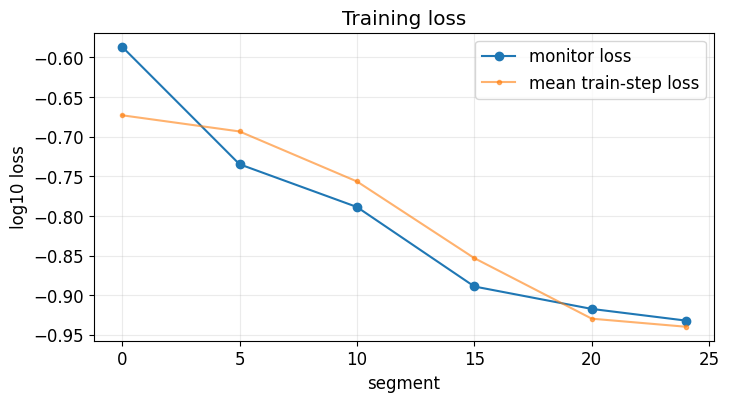

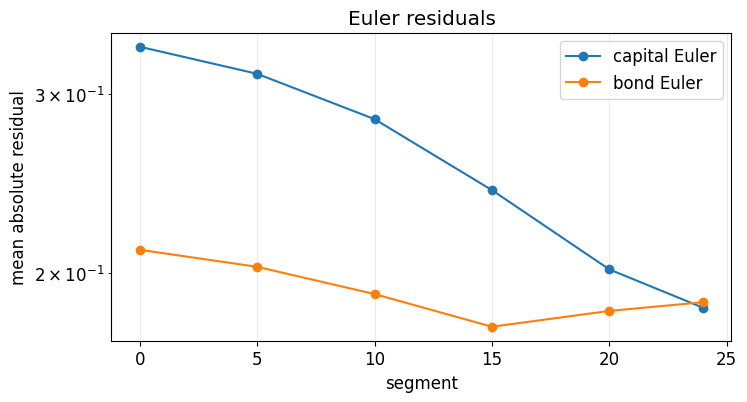

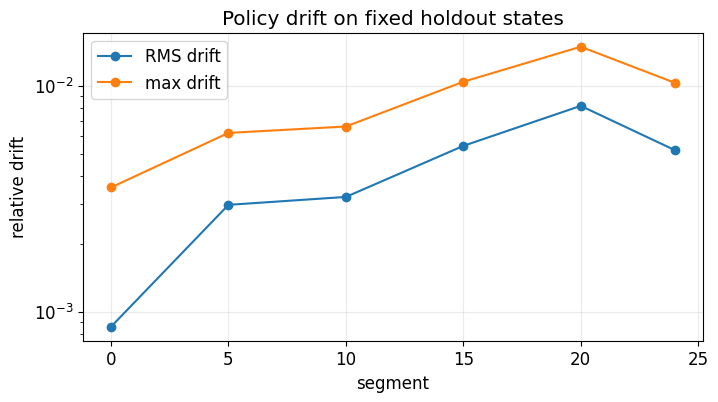

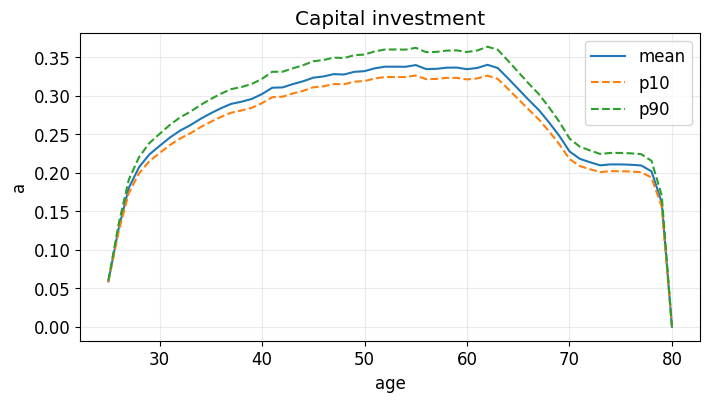

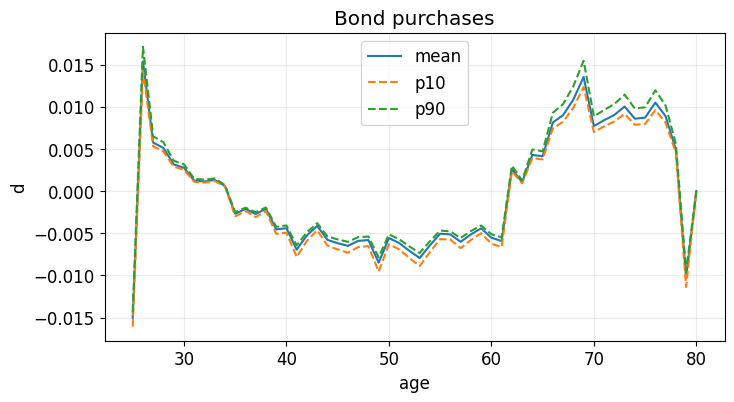

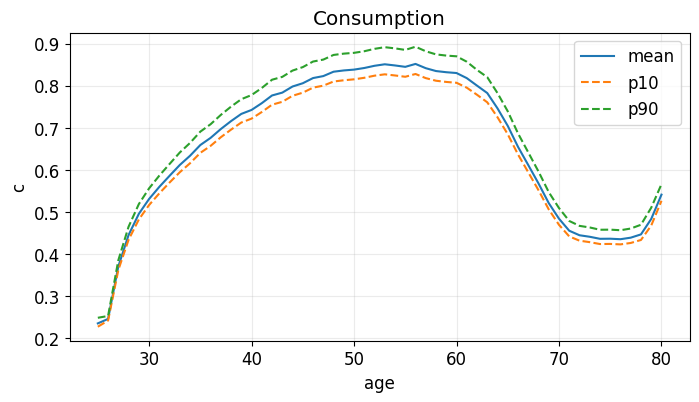

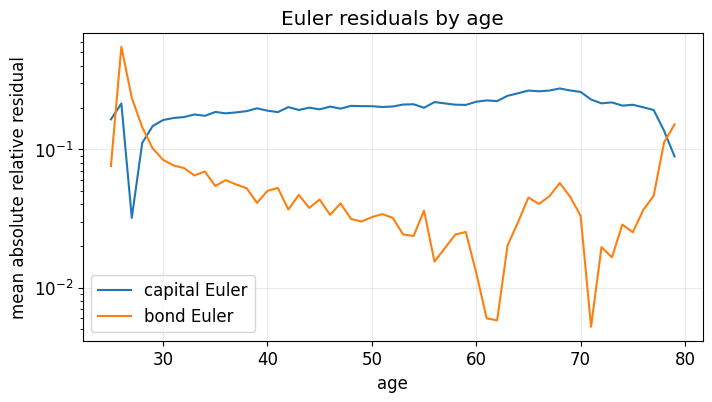

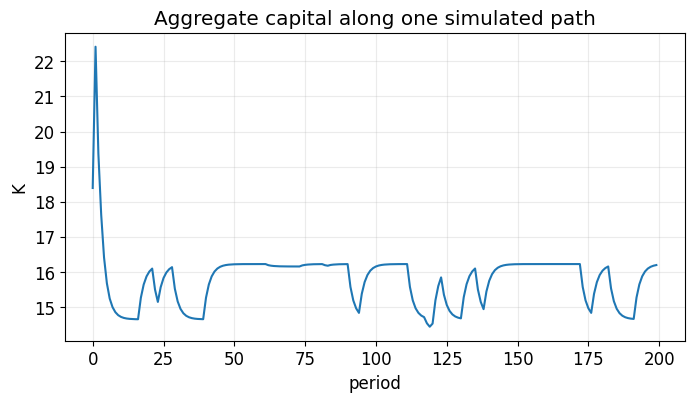

In [10]:
# ============================================================
# Simple plots
# ============================================================
if len(history["segment"]) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], np.log10(np.maximum(history["loss"], 1e-30)), marker="o", label="monitor loss")
    ax.plot(history["segment"], np.log10(np.maximum(history["train_loss"], 1e-30)), marker=".", alpha=0.6, label="mean train-step loss")
    ax.set_xlabel("segment")
    ax.set_ylabel("log10 loss")
    ax.set_title("Training loss")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["mean_abs_euler_capital"], marker="o", label="capital Euler")
    ax.plot(history["segment"], history["mean_abs_euler_bond"], marker="o", label="bond Euler")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("mean absolute residual")
    ax.set_title("Euler residuals")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["segment"], history["policy_drift_rms"], marker="o", label="RMS drift")
    ax.plot(history["segment"], history["policy_drift_max"], marker="o", label="max drift")
    ax.set_yscale("log")
    ax.set_xlabel("segment")
    ax.set_ylabel("relative drift")
    ax.set_title("Policy drift on fixed holdout states")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def lifecycle_statistics(X, model):
    loss, comp = compute_residuals(tf.constant(X, dtype=tf.float32), model)
    a = comp["a"].numpy()
    d = comp["d"].numpy()
    c = comp["c"].numpy()
    a_all = np.concatenate([a, np.zeros((a.shape[0], 1), dtype=np.float32)], axis=1)
    d_all = np.concatenate([d, np.zeros((d.shape[0], 1), dtype=np.float32)], axis=1)
    return a_all, d_all, c


def plot_lifecycle_bands(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 5151).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    a_all, d_all, c = lifecycle_statistics(X, model)
    for label, values, ylab in [
        ("Capital investment", a_all, "a"),
        ("Bond purchases", d_all, "d"),
        ("Consumption", c, "c"),
    ]:
        mean = np.mean(values, axis=0)
        p10 = np.quantile(values, 0.10, axis=0)
        p90 = np.quantile(values, 0.90, axis=0)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(AGES, mean, label="mean")
        ax.plot(AGES, p10, linestyle="--", label="p10")
        ax.plot(AGES, p90, linestyle="--", label="p90")
        ax.set_title(label)
        ax.set_xlabel("age")
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.show()


def plot_residuals_by_age(X, model, max_states=4096):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[0] > max_states:
        idx = np.random.default_rng(SEED + 6161).choice(X.shape[0], size=max_states, replace=False)
        X = X[idx]
    _, comp = compute_residuals(tf.constant(X), model)
    e_cap = np.abs(comp["euler_capital"].numpy())
    e_bond = np.abs(comp["euler_bond"].numpy())
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(AGES[:-1], np.mean(e_cap, axis=0), label="capital Euler")
    ax.plot(AGES[:-1], np.mean(e_bond, axis=0), label="bond Euler")
    ax.set_yscale("log")
    ax.set_xlabel("age")
    ax.set_ylabel("mean absolute relative residual")
    ax.set_title("Euler residuals by age")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


plot_lifecycle_bands(X_eval_sim, model)
plot_residuals_by_age(X_eval_sim, model)

# One illustrative simulated path.
path_one, _, _ = simulate_path(sample_feasible_initial_states(1, seed_offset=9999), model, 200, return_time_major=True)
K_path = path_one[:, 0, 1:1 + N_AGES].sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_path)
ax.set_title("Aggregate capital along one simulated path")
ax.set_xlabel("period")
ax.set_ylabel("K")
ax.grid(alpha=0.25)
plt.show()


## How to use the notebook

For a quick check, keep `MODE = "smoke"`. For a classroom run, use `MODE = "teaching"`.
For a paper-scale run, use `MODE = "production"`; this switches to 1000 hidden units and a long two-stage schedule. The production preset is intended for a GPU or distributed run.

The key point is the data-generation mode. In the exogenous notebook, every segment is an independent feasible state cloud. In the simulation notebook, each segment is generated by the current policy and the terminal states are used to start the next segment. In both cases, the diagnostics evaluate residuals on both exogenous and simulated out-of-sample clouds.
